In [1]:
# Import neccesary libraries.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import randint

# Current Approach in improving performance
 - Remove Outliers
 - Remove high dependent variables
 - Use regularization methods
 - Use deep neural networks
 - check assumption
 - Transform the response variable for stable distribution
 - Create more measures (utilities) from the data (e.g. Star Powers)

### Load data and check response distribution

In [2]:
df = pd.read_csv("data/movie_data_encoded.csv")
y = df['revenue']
columns_to_drop = ['Unnamed: 0', 'name', 'genres', 'directors', 'writers','actors', 'original_language', 'production_companies',
       'release_date','keywords', 'revenue']
X = df.drop(columns_to_drop, axis=1)
y_log = np.log1p(y)

In [3]:
def check_revenue_distribution(series):
    plt.figure(figsize=(8,5))
    sns.histplot(series, bins=50, kde=True)
    plt.title("Revenue Distribution")
    plt.show()

In [4]:
#check_revenue_distribution(y)

In [5]:
#check_revenue_distribution(y_log)

### Transform Data and do train/test split

In [6]:
# Check VIF of each variable
vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)
              for i in range(len(X.columns))]

c:\Users\wue77\anaconda3\envs\movie_env\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\wue77\anaconda3\envs\movie_env\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


In [8]:
for i in vif[vif["VIF"] > 10]['feature']:
    X.drop(i, axis=1)

In [9]:
# Split original data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply log1p to y_train only
y_train_log = np.log1p(y_train)  # Train on log-transformed target

# Create polynomial features (For complex interaction)
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

feature_names = poly.get_feature_names_out(X.columns)

# Scale features using training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaler_poly = StandardScaler()
X_train_poly_scaled = scaler_poly.fit_transform(X_train_poly)
X_test_poly_scaled = scaler_poly.transform(X_test_poly)

In [10]:
# Check the performance of the dummy variable
dummy_pred = np.full_like(y_test, y_train.mean())
RMSE = np.sqrt(mean_squared_error(y_test, dummy_pred))
R2 = r2_score(y_test, dummy_pred)

# Format RMSE (e.g., in millions)
print(f"RMSE: {round(RMSE / 1e6, 2)} Millions, R²: {round(R2, 2)}")

RMSE: 41.3 Millions, R²: -0.0


In [ ]:
RFR_tune = RandomForestRegressor()
param_dist = {
    'n_estimators': [100, 300, 500, 1000],
    'max_depth': [5, 10, 20, 30, None],
    'min_samples_split': [2, 5, 10],  # Prevents overfitting
    'min_samples_leaf': [1, 2, 4],  # Controls minimum samples per leaf
    'max_features': ['sqrt', 'log2', 0.5, None]  # Feature selection method
}

rand_search = RandomizedSearchCV(RFR_tune, param_distributions=param_dist, n_iter=10, cv=5, random_state=42, n_jobs=-1)

# Fit the random search object to the data.
rand_search.fit(X_train, y_train.values.ravel())
rand_search.best_estimator_

Exception in thread ExecutorManagerThread:
Traceback (most recent call last):
  File "c:\Users\wue77\anaconda3\envs\movie_env\Lib\site-packages\psutil\_pswindows.py", line 726, in wrapper
    return fun(self, *args, **kwargs)
  File "c:\Users\wue77\anaconda3\envs\movie_env\Lib\site-packages\psutil\_pswindows.py", line 914, in kill
    return cext.proc_kill(self.pid)
           ~~~~~~~~~~~~~~^^^^^^^^^^
PermissionError: [WinError 5] Access is denied: '(originated from OpenProcess)'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Users\wue77\anaconda3\envs\movie_env\Lib\threading.py", line 1041, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "c:\Users\wue77\anaconda3\envs\movie_env\Lib\site-packages\joblib\externals\loky\process_executor.py", line 608, in run
    self.flag_executor_shutting_down()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\wue77\anaconda3\envs\movie_env\Lib\site-packages\joblib\exte

KeyboardInterrupt: 

In [ ]:
RFR = RandomForestRegressor(max_features=None, min_samples_leaf=4, min_samples_split=5, n_estimators=300, oob_score=True, random_state=42)
RFR.fit(X_train_poly, y_train_log.values.ravel())
y_pred = np.expm1(RFR.predict(X_test_poly))
RMSE = np.sqrt(mean_squared_error(y_test, y_pred))
R2 = r2_score(y_test, y_pred)
# Format RMSE (e.g., in millions)
print(f"RMSE: {round(RMSE / 1e6, 2)} Millions, R²: {round(R2, 2)}")

RMSE: 27.32 Millions, R²: 0.56


In [50]:
RFR.oob_score_

0.4889589380149937

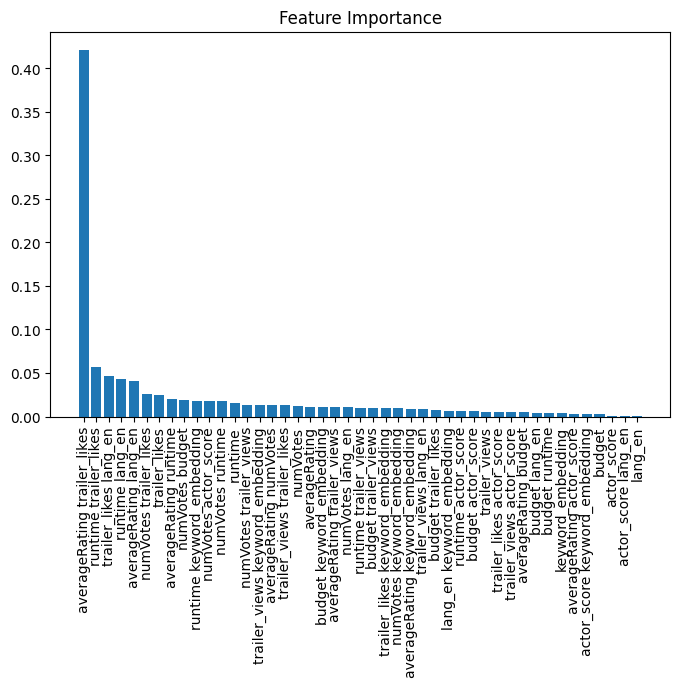

In [64]:
importances = RFR.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot feature importance
plt.figure(figsize=(8, 5))
plt.title("Feature Importance")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), np.array(feature_names)[indices], rotation=90)
plt.show()